# Full study: eight parts, one odd point, one price

The inspection table:

| Length | Weight | Label |
|---:|---:|---|
| 1 | 1 | pass |
| 1 | 2 | pass |
| 2 | 1 | pass |
| 2 | 2 | pass |
| 1 | 4 | fail |
| 2 | 4 | fail |
| 5 | 1 | fail |
| 5 | 2 | fail |

Parent Gini is $1/2$. Length $\le 7/2$ and weight $\le 3$ both gain $1/6$. Length is listed first, so it asks the root question. The left child then asks weight $\le 3$ and both of its leaves are pure.


In [1]:
# Root gain 1/6, second gain 4/9, and three walks.
from fractions import Fraction

def predict(length, weight):
    if length <= Fraction(7, 2):
        if weight <= 3:
            return "pass"
        return "fail"
    return "fail"

assert predict(2, 2) == "pass"
assert predict(5, 1) == "fail"
assert predict(1, 4) == "fail"
assert Fraction(1, 2) - Fraction(1, 3) == Fraction(1, 6)
assert Fraction(4, 9) - 0 == Fraction(4, 9)
print("short light", predict(2, 2))
print("long light", predict(5, 1))
print("short heavy", predict(1, 4))


short light pass
long light fail
short heavy fail


## The rectangle, the odd point, and the price of a leaf

The picture is the pass rectangle. Separately, the line of ten measurements memorized $x = 10$ unless a leaf has a price. At $\alpha = 1/8$ the two-leaf cost is $7/20$, which beats $3/8$ and $17/40$.

The regression cut is the same kind of comparison on squared error. Yields $2, 2, 8, 8$ cost $36$ as one leaf and $0$ after the cut at $5/2$.


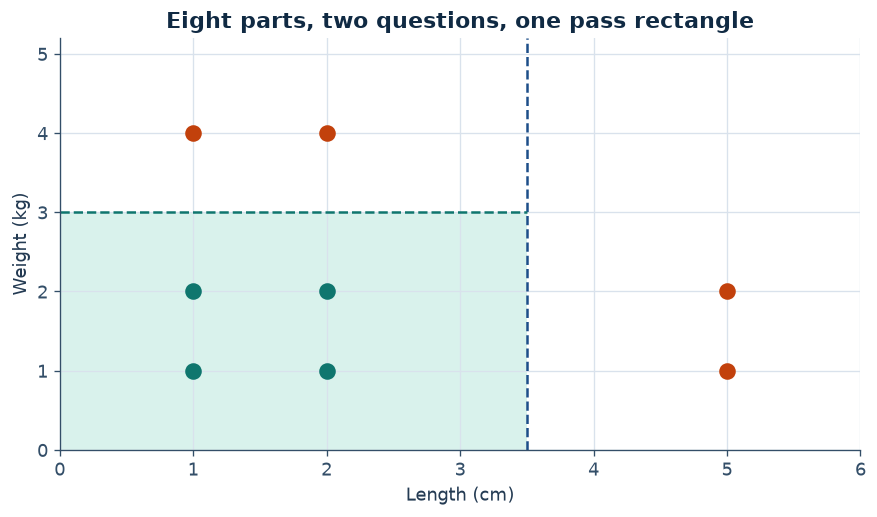

In [2]:
import matplotlib.pyplot as plt

# Quiet page. Pass is green, fail is clay, and the grid stays behind the marks.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# One picture for the inspection tree.
parts = [
    (1, 1, "pass"), (1, 2, "pass"), (2, 1, "pass"), (2, 2, "pass"),
    (1, 4, "fail"), (2, 4, "fail"), (5, 1, "fail"), (5, 2, "fail"),
]
fig, ax = plt.subplots(constrained_layout=True)
ax.add_patch(plt.Rectangle((0, 0), 3.5, 3, facecolor="#d9f2ec", edgecolor="none", zorder=0))
ax.axvline(3.5, color=BLUE, linestyle="--")
ax.plot([0, 3.5], [3, 3], color=GREEN, linestyle="--")
for length, weight, label in parts:
    ax.scatter(length, weight, s=80, color=GREEN if label == "pass" else CLAY, zorder=3)
ax.set_xlim(0, 6)
ax.set_ylim(0, 5.2)
ax.set_xlabel("Length (cm)")
ax.set_ylabel("Weight (kg)")
ax.set_title("Eight parts, two questions, one pass rectangle")


In [3]:
# The price check and the regression check, side by side with the tree.
from fractions import Fraction

alpha = Fraction(1, 8)
assert Fraction(1, 10) + 2 * alpha == Fraction(7, 20)
assert 3 * alpha == Fraction(3, 8)
assert Fraction(7, 20) < Fraction(3, 8)
yields = [2, 2, 8, 8]
mean = Fraction(sum(yields), 4)
parent = sum((y - mean) ** 2 for y in yields)
assert parent == 36
assert mean == 5
print("two-leaf cost", Fraction(7, 20))
print("regression parent SSE", parent)


two-leaf cost 7/20
regression parent SSE 36


## What this path was

1. A tree predicts by walking questions until a leaf.
2. A class leaf names the majority, because that minimizes the error count.
3. Gini, $2p(1-p)$, sees a useful cut when the error rate does not. Entropy is the same idea in bits.
4. The chosen question maximizes the drop in impurity. One midpoint per gap is enough, and a tie needs a written rule.
5. A number leaf predicts the mean, because that constant minimizes squared error.
6. A leaf of size $1$ can memorize. $\alpha$ is the price that removes it.
7. Feature credit is the impurity that feature removed, and a tied root can swap the ranking.
8. The regions are rectangles. XOR shows a first cut with gain $0$ that a later cut redeems.

On the eight parts the sentences are: length asks first, weight finishes the job, and a part passes only inside length $\le 7/2$ and weight $\le 3$.
